# Q9.
```{admonition}
:class: note
This question involves the use of multiple linear regression on the `Auto` data set

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

In [11]:
import seaborn as sns

In [52]:
import statsmodels.api as sm
from ISLP.models import ModelSpec as MS, summarize

In [ ]:
auto = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/Auto.csv',na_values=['?']).dropna()

## (a)
```{admonition}
:class: note
Produce a scatterplot matrix which includes all of the variables in the data set.

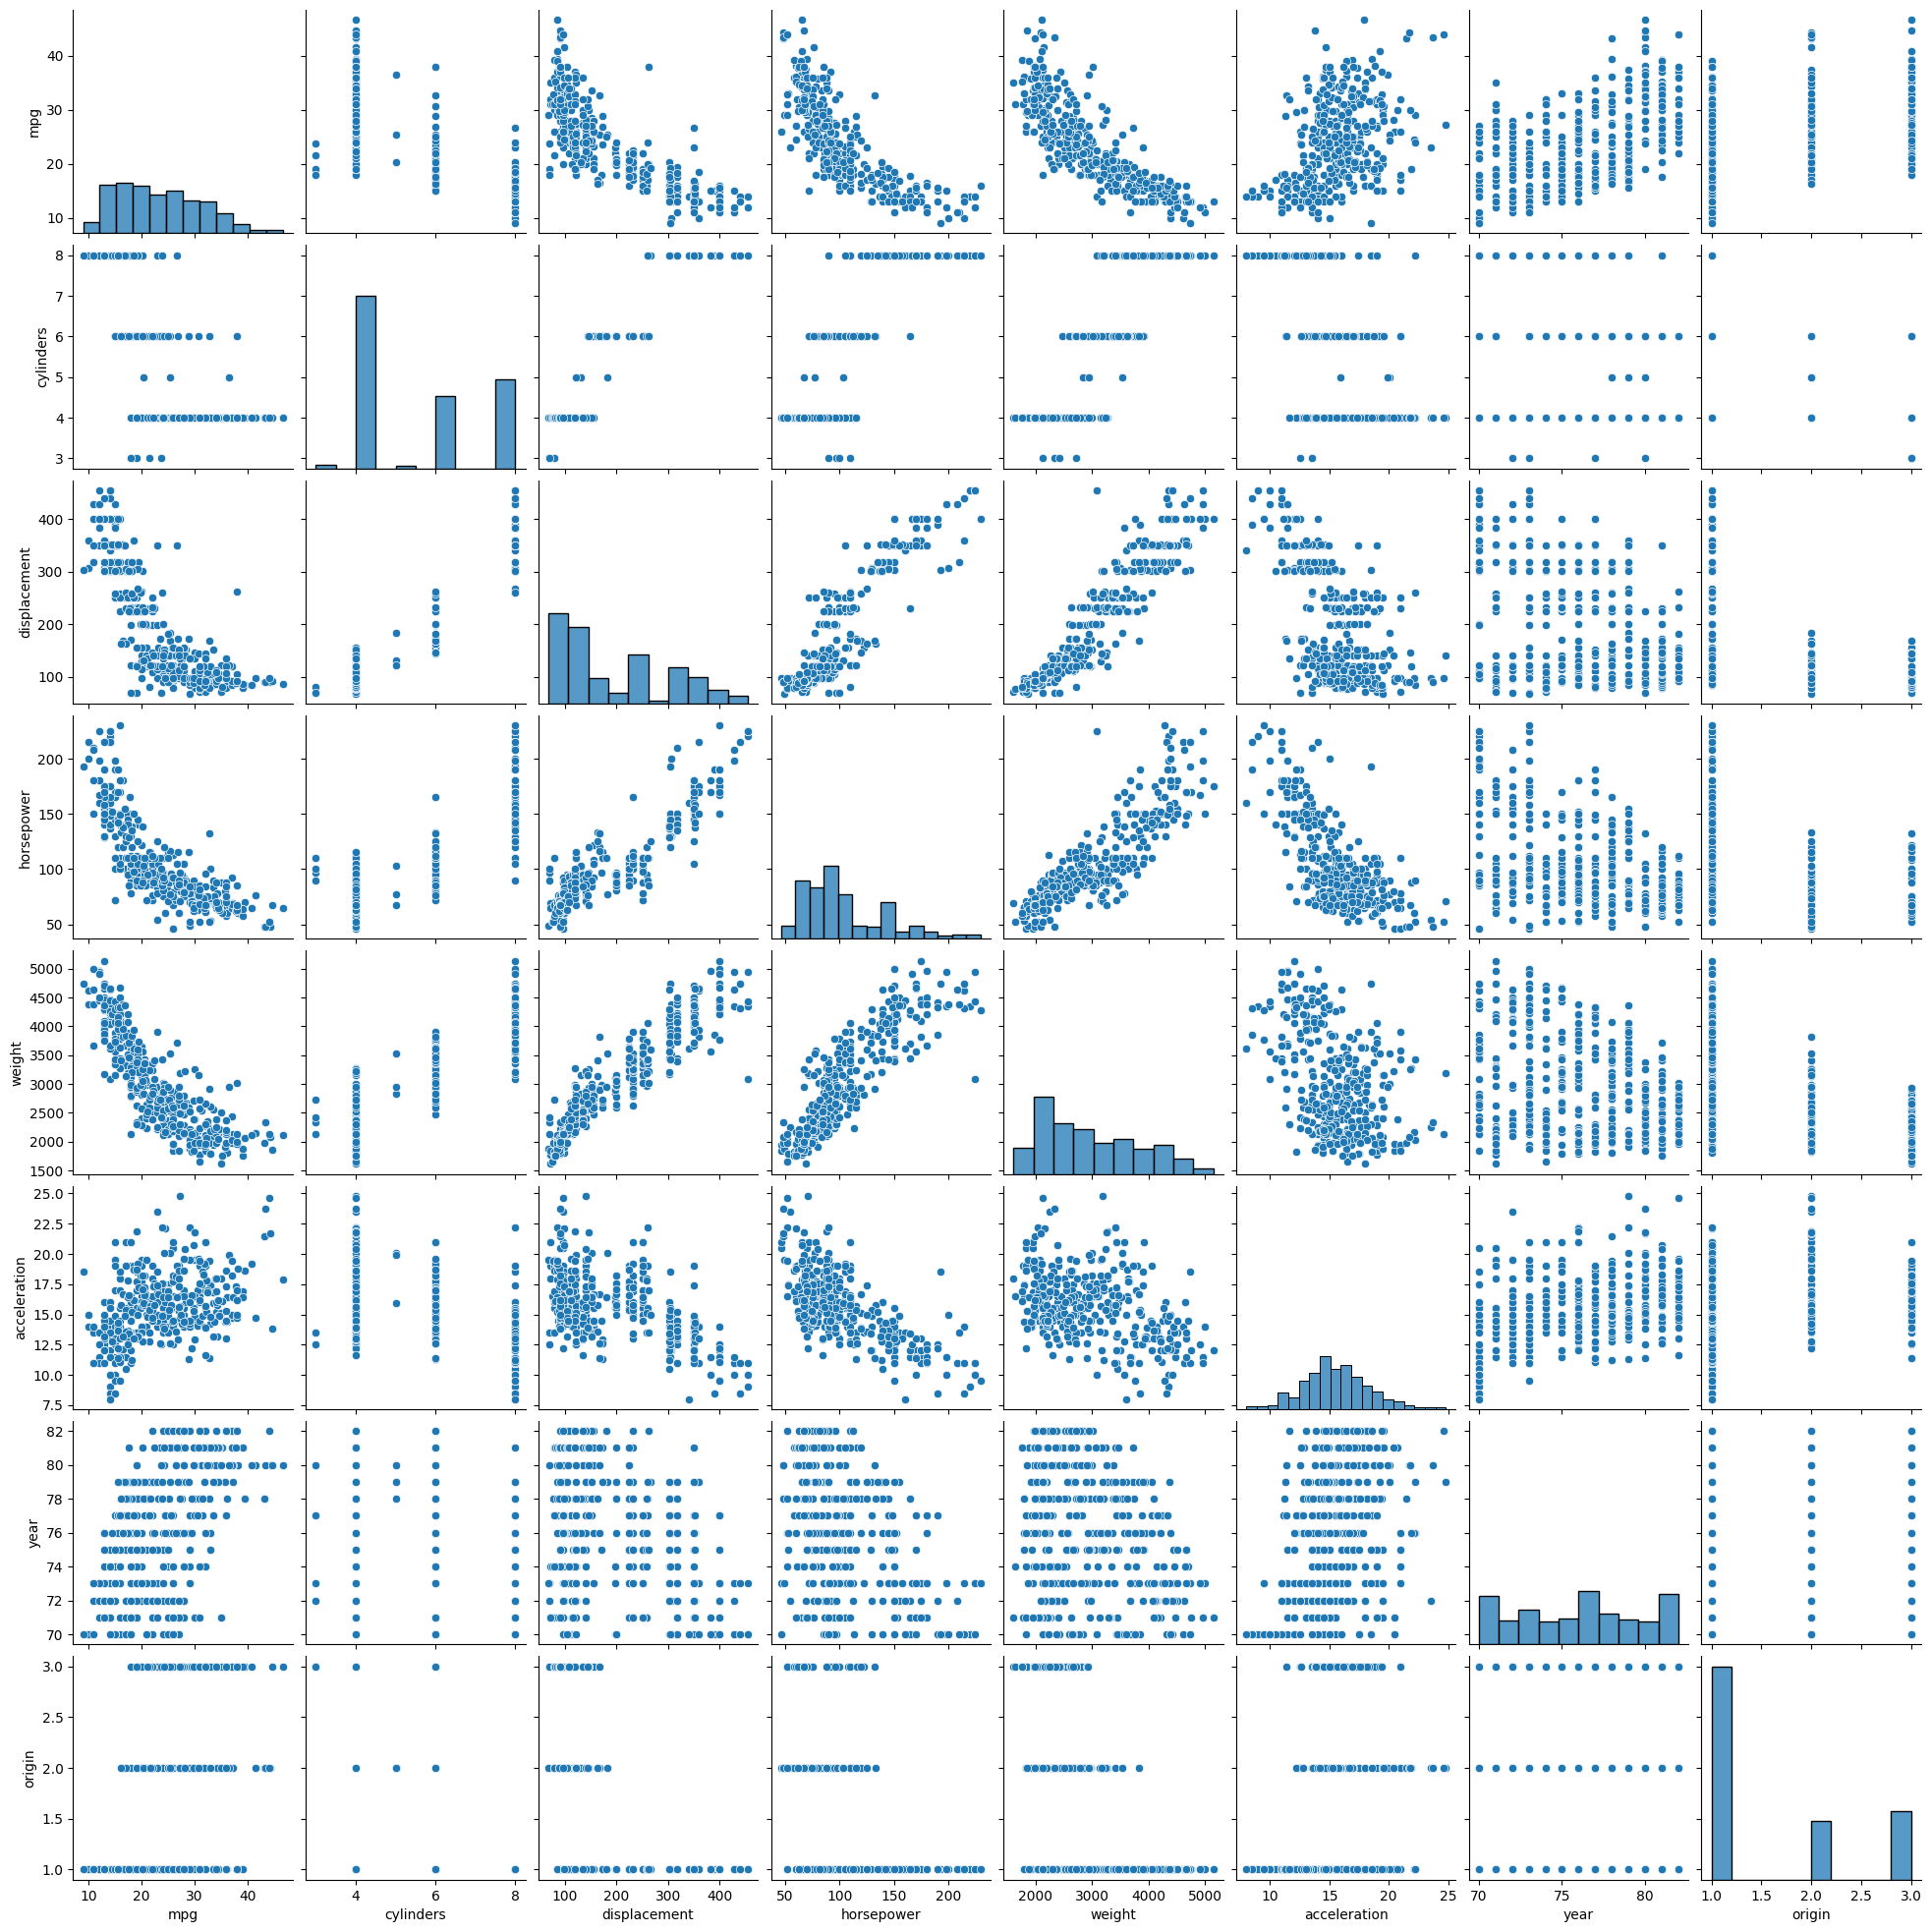

In [13]:
sns.pairplot(auto) ;

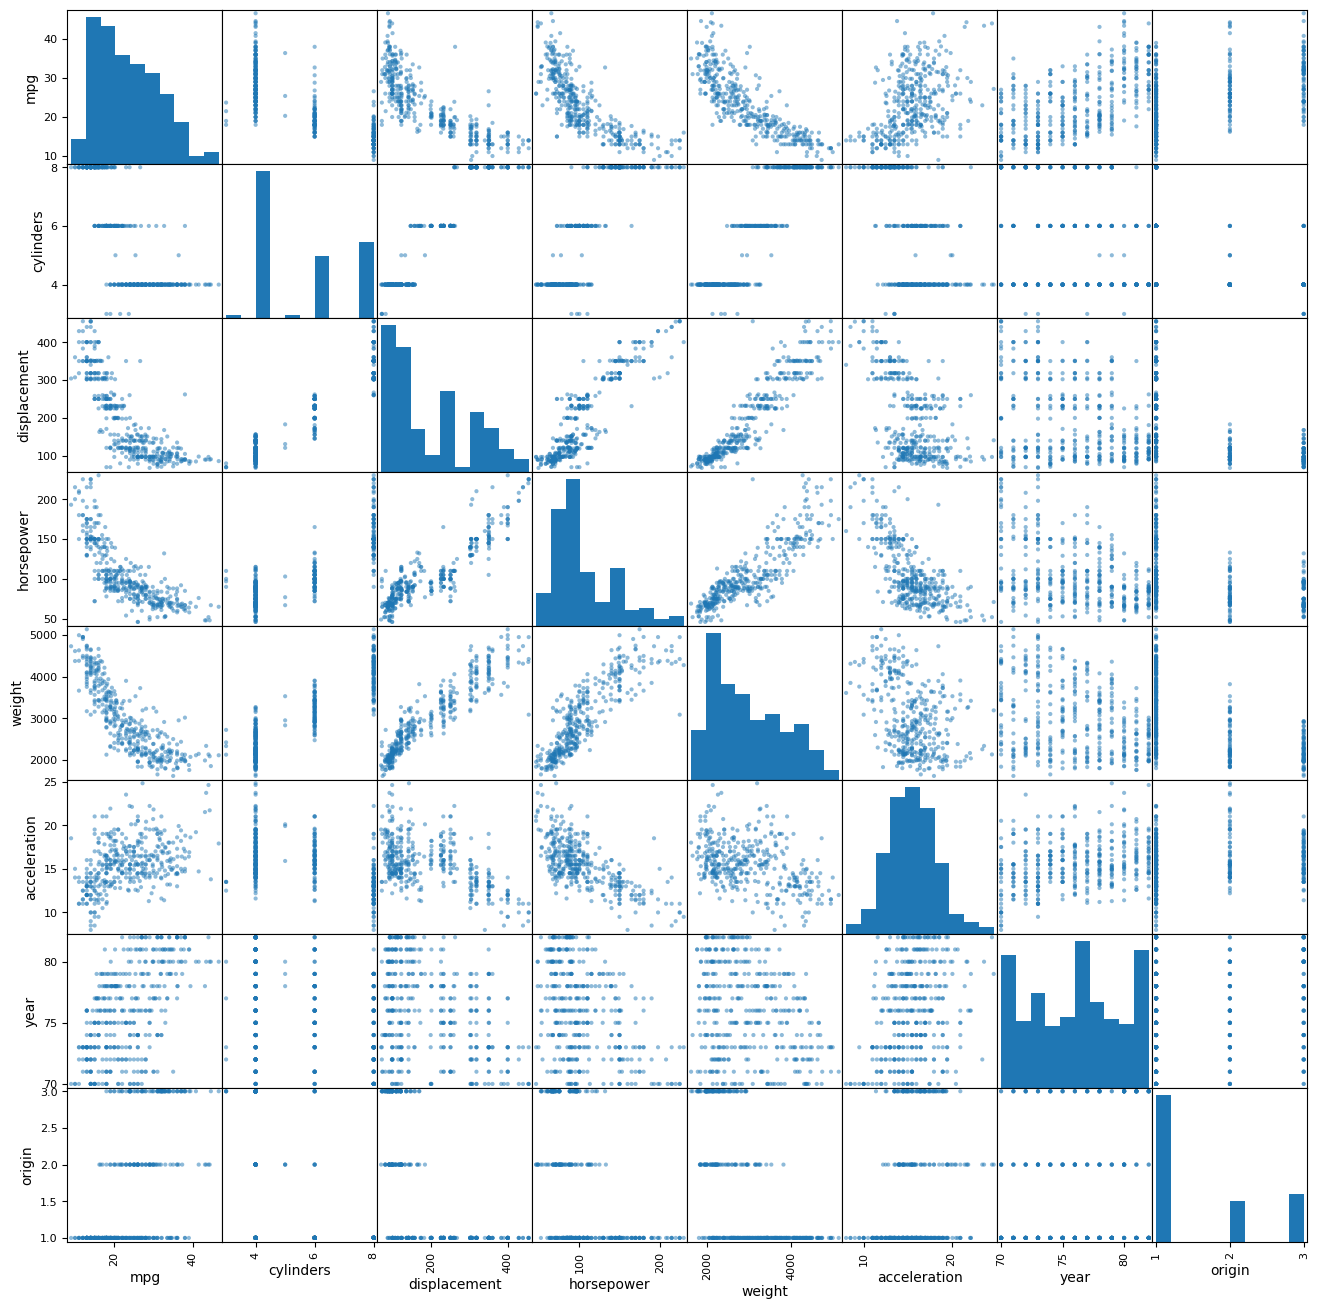

In [22]:
fig, ax = subplots(8,8,figsize=(16,16))
pd.plotting.scatter_matrix(auto, ax =ax) ;

## (b)
```{admonition}
:class: note
Compute the matrix of correlations betwween the variabels using the `DataFrame.corr()` method.

In [31]:
auto.drop(columns = ['name']).corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


In [32]:
auto.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


## (c)
```{admonition}
:class: note
Use the `sm.OLS()` function to perform a multiple linear regression with `mpg` as the response and all other variables except name as the predictors. Use the `summarize()` function to print the results. Comment on the output. For instance:

i. Is there a relationship between the predictors and the response? Use the `anova_lm()` function from `statsmodels` to answer this question.

ii. Which predictors appear to have a statistically significant relationship to the response?

iii. What does the coefficient for the `year` variable suggest?

In [57]:
X = auto.drop(columns=['name','mpg'])
X = sm.add_constant(X)
y = auto['mpg']
model_sm1 = sm.formula.ols('mpg ~ (cylinders+displacement+horsepower+weight+acceleration+year+origin)', auto).fit()
model_sm2 = sm.OLS(y,X).fit()
summarize(model_sm2)

,coef,std err,t,P>|t|
const,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [58]:
summarize(model_sm1)

,coef,std err,t,P>|t|
Intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [67]:
sm.stats.anova_lm(model_sm1,typ=2)

,sum_sq,df,F,PR(>F)
cylinders,25.791491,1.0,2.329125,1.277965e-01
displacement,77.612668,1.0,7.008884,8.444649e-03
horsepower,16.739754,1.0,1.511699,2.196328e-01
weight,1091.631693,1.0,98.580813,7.874953e-21
acceleration,7.358417,1.0,0.664509,4.154780e-01
year,2402.249906,1.0,216.937408,3.055983e-39
origin,291.134494,1.0,26.291171,4.665681e-07
Residual,4252.212530,384.0,NaN,NaN


In [66]:
f_pval = model_sm2.f_pvalue
print(f'The p-value is {f_pval:.3e} indicating a relationship exists between the predictors and response.')

The p-value is 2.037e-139 indicating a relationship exists between the predictors and response.


We see that `displacement`, `weight`, `year`, and `origin` have low $p$-values, indicating a statistically significant relationship.

The coefficient of `year` is postive, which suggests that newer cars have better `mpg` assuming all other variables are constant.

## (d)
```{admonition}
:class: note
Produce some of diagnostic plots of the linear regression fit as described in the lab. Comment on any problems you see with the fit. Do the residual plots suggest any unusually large outliers? Does the leverage plot identify any observations with unusually high leverage?

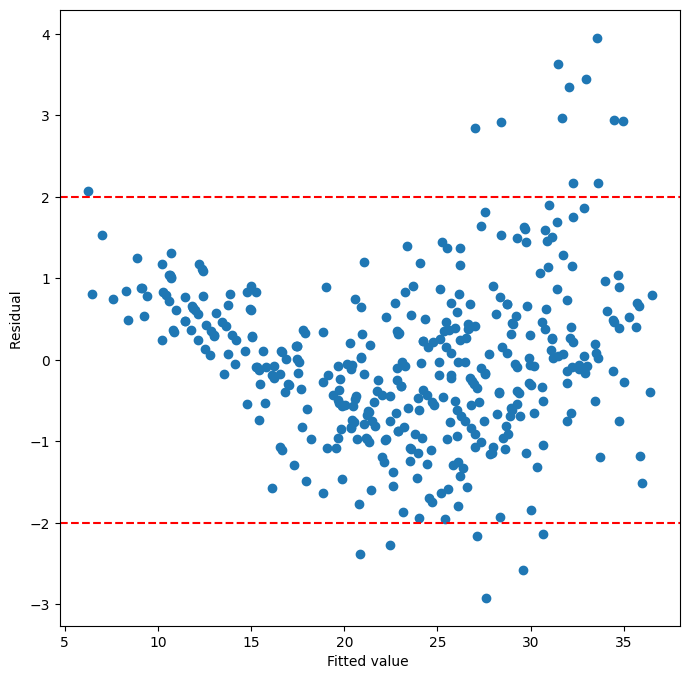

In [105]:
infl = model_sm2.get_influence()
ax = subplots(figsize =(8 ,8))[1]
ax.scatter(model_sm2.fittedvalues , infl.resid_studentized_internal)
ax.set_xlabel('Fitted value ')
ax.set_ylabel('Residual ')
#ax.axhline(0, c='k', ls='--')
ax.axhline(2, c='r', ls='--')
ax.axhline(-2, c='r', ls='--');

np.int64(13)

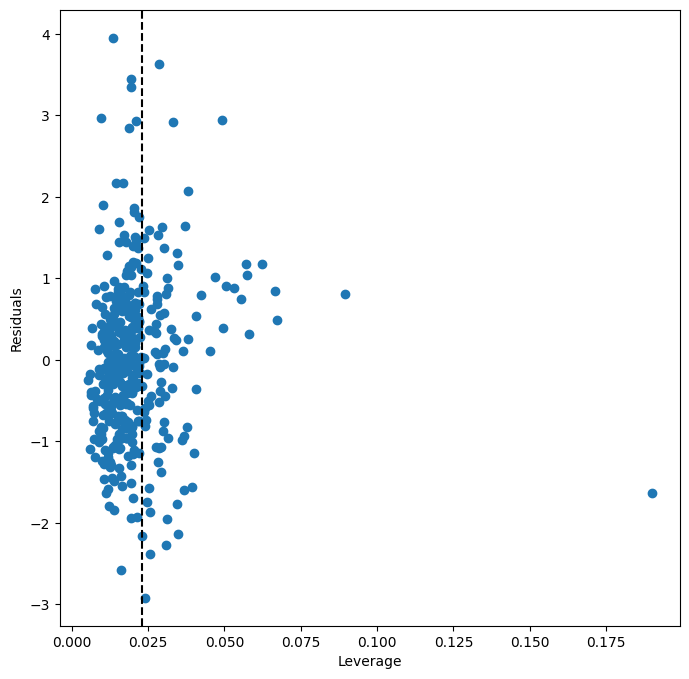

In [100]:
infl = model_sm2.get_influence()
n = auto.shape[0]
p = auto.shape[1]
ax = subplots(figsize =(8 ,8))[1]
ax.scatter(infl.hat_matrix_diag,infl.resid_studentized_internal)
ax.set_xlabel('Leverage')
ax.set_ylabel('Residuals')
ax.axvline(p/n, c='k', ls='--');
np.argmax(infl.hat_matrix_diag)

In [150]:
auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
394,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
395,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


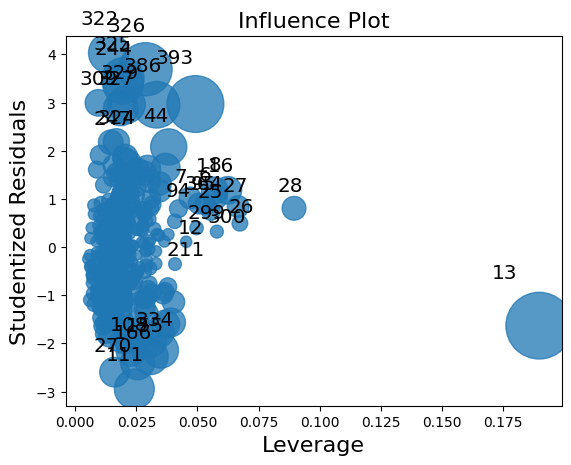

In [93]:
#fig, ax = subplots(figsize=(8,8))
sm.graphics.influence_plot(model_sm2)
plt.show()

## (e)
```{admonition}
:class: note
Fit some models with interactions as described in the lab. Do any interactions appear to be statistically significant.

In [121]:
model_sm1_interact1 = sm.formula.ols('mpg ~ (cylinders+displacement+horsepower+weight+acceleration+year+origin)**2', auto).fit()
s = summarize(model_sm1_interact1)
s[s['P>|t|'] < 0.05]

,coef,std err,t,P>|t|
displacement,-0.4785,0.189,-2.527,0.012
acceleration,-5.8592,2.174,-2.696,0.007
origin,-20.8956,7.097,-2.944,0.003
displacement:year,0.0059,0.002,2.482,0.014
acceleration:year,0.0556,0.026,2.174,0.030
acceleration:origin,0.4583,0.157,2.926,0.004


In [135]:
model_sm1_interact1.rsquared_adj

np.float64(0.8808149586594882)

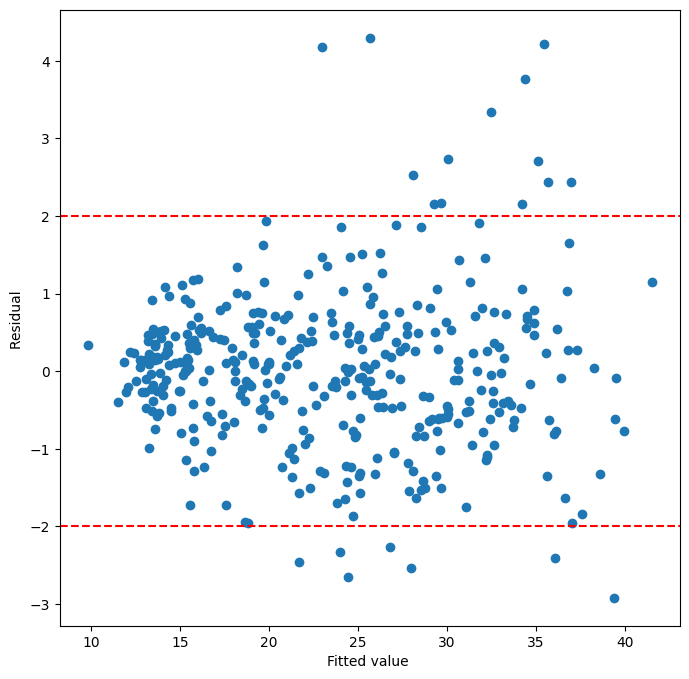

In [124]:
infl = model_sm1_interact1.get_influence()
ax = subplots(figsize =(8 ,8))[1]
ax.scatter(model_sm1_interact2.fittedvalues , infl.resid_studentized_internal)
ax.set_xlabel('Fitted value ')
ax.set_ylabel('Residual ')
#ax.axhline(0, c='k', ls='--')
ax.axhline(2, c='r', ls='--')
ax.axhline(-2, c='r', ls='--');

In [122]:
model_sm1_interact2 = sm.formula.ols('mpg ~ (displacement+weight+acceleration+year+origin)**2', auto).fit()
s = summarize(model_sm1_interact2)
s[s['P>|t|'] < 0.05]

,coef,std err,t,P>|t|
Intercept,107.224200,36.673000,2.924,0.004
displacement,-0.238700,0.100000,-2.380,0.018
acceleration,-7.745000,1.498000,-5.169,0.000
origin,-19.335800,5.499000,-3.516,0.000
displacement:weight,0.000023,0.000003,6.829,0.000
displacement:origin,0.037100,0.012000,2.999,0.003
acceleration:year,0.084600,0.019000,4.515,0.000
acceleration:origin,0.546600,0.112000,4.860,0.000


In [133]:
model_sm1_interact2.rsquared_adj

np.float64(0.8758680429102008)

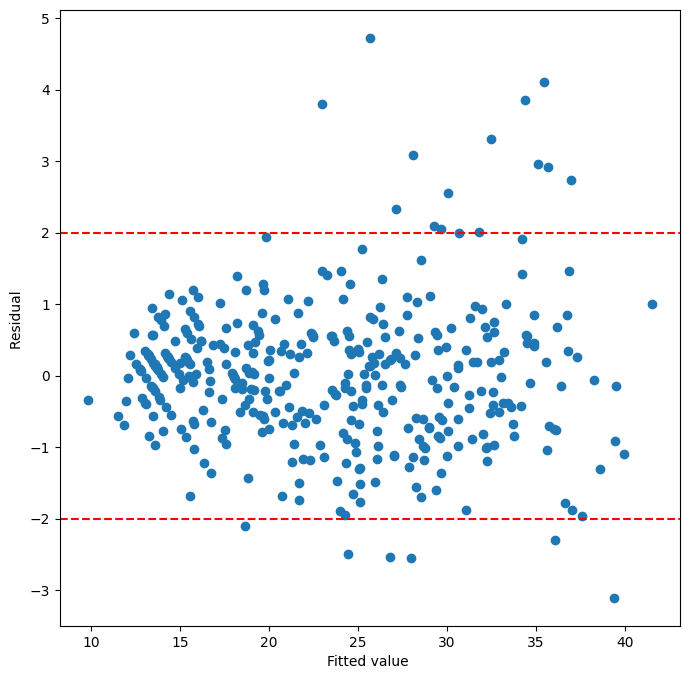

In [123]:
infl = model_sm1_interact2.get_influence()
ax = subplots(figsize =(8 ,8))[1]
ax.scatter(model_sm1_interact2.fittedvalues , infl.resid_studentized_internal)
ax.set_xlabel('Fitted value ')
ax.set_ylabel('Residual ')
#ax.axhline(0, c='k', ls='--')
ax.axhline(2, c='r', ls='--')
ax.axhline(-2, c='r', ls='--');

In [125]:
model_sm1_interact3 = sm.formula.ols('mpg ~ displacement+acceleration+origin+displacement:weight+displacement:origin+acceleration:year+acceleration:origin', auto).fit()
s = summarize(model_sm1_interact3)
s[s['P>|t|'] < 0.05]

,coef,std err,t,P>|t|
Intercept,47.4589,3.973,11.944,0.000
acceleration,-5.0443,0.315,-16.017,0.000
origin,-7.0127,2.350,-2.984,0.003
displacement:origin,-0.0294,0.009,-3.449,0.001
acceleration:year,0.0501,0.003,15.493,0.000
acceleration:origin,0.6933,0.110,6.280,0.000


In [134]:
model_sm1_interact3.rsquared_adj

np.float64(0.805294837422901)

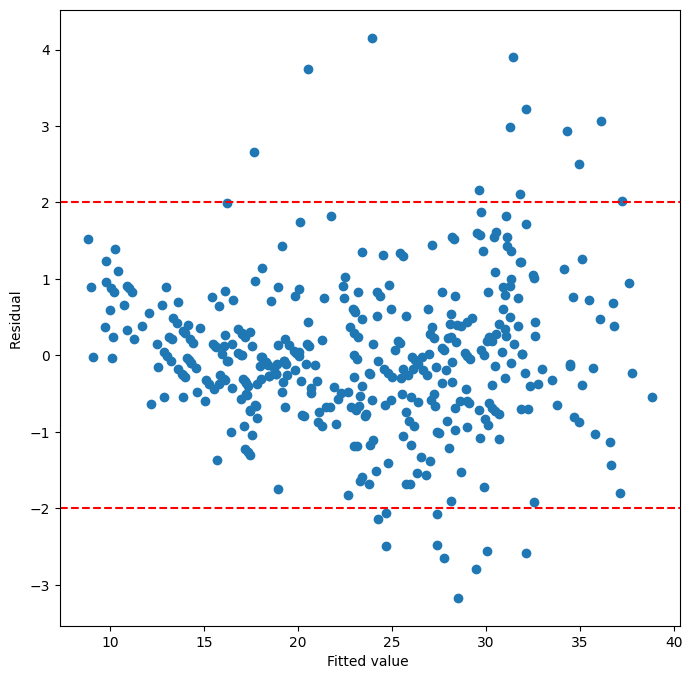

In [126]:
infl = model_sm1_interact3.get_influence()
ax = subplots(figsize =(8 ,8))[1]
ax.scatter(model_sm1_interact3.fittedvalues , infl.resid_studentized_internal)
ax.set_xlabel('Fitted value ')
ax.set_ylabel('Residual ')
#ax.axhline(0, c='k', ls='--')
ax.axhline(2, c='r', ls='--')
ax.axhline(-2, c='r', ls='--');

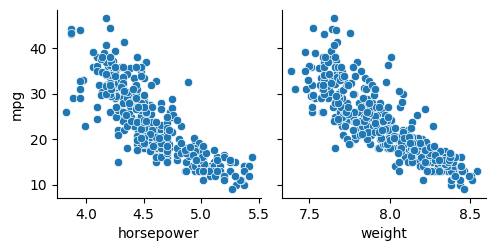

In [145]:
auto_trans = auto.copy()
auto_trans[['horsepower','weight']] = auto_trans[['horsepower','weight']].map(lambda x : np.log(x))
sns.pairplot(auto_trans, x_vars = ['horsepower','weight'], y_vars = ['mpg']) ;

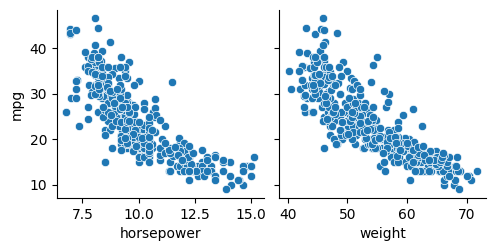

In [146]:
auto_trans = auto.copy()
auto_trans[['horsepower','weight']] = auto_trans[['horsepower','weight']].map(lambda x : np.sqrt(x))
sns.pairplot(auto_trans, x_vars = ['horsepower','weight'], y_vars = ['mpg']) ;

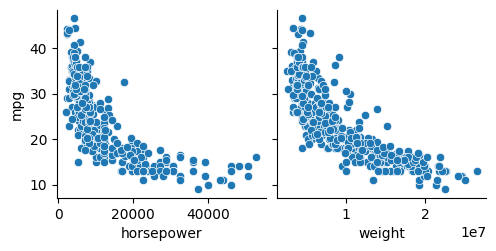

In [148]:
auto_trans = auto.copy()
auto_trans[['horsepower','weight']] = auto_trans[['horsepower','weight']].map(lambda x : x**2)
sns.pairplot(auto_trans, x_vars = ['horsepower','weight'], y_vars = ['mpg']) ;